# PBMC 3K Multiome — Post-Processing Analysis

This notebook is a companion to the [PBMC 3K Multiome tutorial](../PBMC_3k_multiome.md). It assumes you have already run the `cellranger-snakemake` pipeline and have a processed output directory at `3K_PBMC_MULTIOME_PROCESSED/`.

**What this notebook covers:**
1. Loading the pipeline output
2. Inspecting the MuData object and traceability metadata
3. GEX quality control
4. ATAC quality control
5. Doublet score inspection

## Setup

Set `H5MU_PATH` to the path of your pipeline output file.

In [2]:
import muon as mu
import scanpy as sc

# Path to the final pipeline output — update this to match your output directory
H5MU_PATH = "../PBMC_3K_MULTIOME/3K_PBMC_MULTIOME_PROCESSED/08_FINAL/1_arc.h5mu"

/project/lbarreiro/USERS/mschechter/miniconda3/envs/snakemake8/lib/python3.12/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


## Load the data

In [3]:
mdata = mu.read(H5MU_PATH)
mdata

/project/lbarreiro/USERS/mschechter/miniconda3/envs/snakemake8/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/project/lbarreiro/USERS/mschechter/miniconda3/envs/snakemake8/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 3009 × 117757
  obs:	'batch_id', 'capture_id', 'cell_id'
  var:	'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
  2 modalities
    atac:	3009 x 81156
      obs:	'batch_id', 'capture_id', 'cell_id', 'barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'doublet_scrublet_scrublet_score', 'doublet_scrublet_scrublet_predicted_doublet'
      var:	'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    gex:	3009 x 36601
      obs:	'batch_id', 'capture_id', 'cell_id', 'barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_scrublet_scrublet_score', 'doublet_scrublet_scrublet_predicted_doublet'
      var:	'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

## Verify traceability metadata

Every cell should have `batch_id`, `capture_id`, and a globally unique `cell_id`.

In [4]:
assert "batch_id" in mdata.obs.columns
assert "capture_id" in mdata.obs.columns
assert "cell_id" in mdata.obs.columns
assert mdata.obs["cell_id"].is_unique, "cell_id must be unique!"

print(f"Total cells : {mdata.n_obs}")
print(f"Modalities  : {list(mdata.mod.keys())}")
print(f"GEX shape   : {mdata['gex'].shape}")
print(f"ATAC shape  : {mdata['atac'].shape}")
print()
print(mdata.obs[["batch_id", "capture_id", "cell_id"]].head())

Total cells : 3009
Modalities  : ['atac', 'gex']
GEX shape   : (3009, 36601)
ATAC shape  : (3009, 81156)

                       batch_id capture_id                 cell_id
1_A_AAACAGCCAACAGGTG-1        1          A  1_A_AAACAGCCAACAGGTG-1
1_A_AAACATGCAACAACAA-1        1          A  1_A_AAACATGCAACAACAA-1
1_A_AAACATGCACCTGGTG-1        1          A  1_A_AAACATGCACCTGGTG-1
1_A_AAACCAACACAGCCTG-1        1          A  1_A_AAACCAACACAGCCTG-1
1_A_AAACCAACAGCAAGAT-1        1          A  1_A_AAACCAACAGCAAGAT-1


## GEX quality control

Key metrics to inspect:
- `total_counts` — total UMI counts per cell
- `n_genes_by_counts` — number of detected genes per cell
- `pct_counts_mt` — percent mitochondrial counts (high values indicate damaged cells)

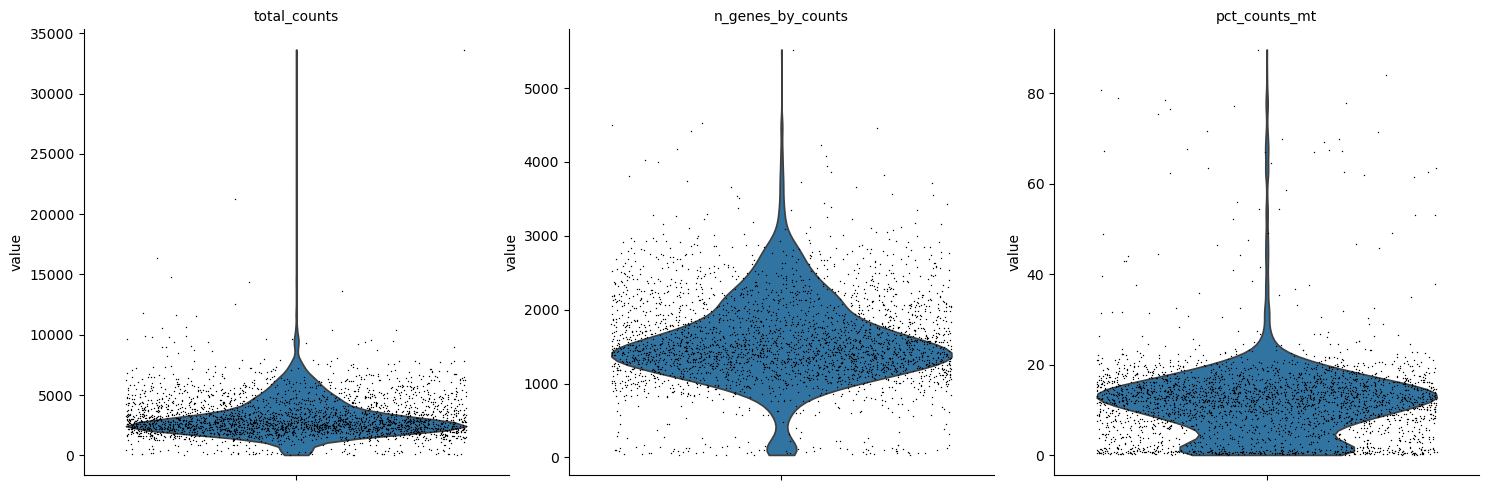

In [5]:
sc.pl.violin(
    mdata["gex"],
    ["total_counts", "n_genes_by_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

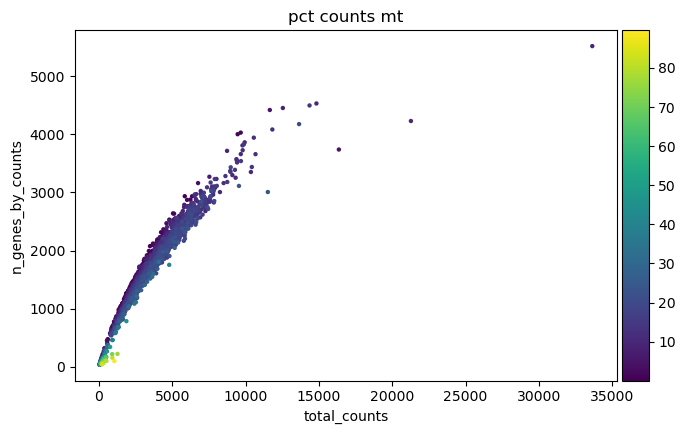

In [6]:
sc.pl.scatter(
    mdata["gex"],
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt",
)

## ATAC quality control

Key metrics to inspect:
- `total_counts` — total fragment counts per cell
- `n_genes_by_counts` — number of peaks detected per cell (named `n_genes_by_counts` for consistency with scanpy's API)

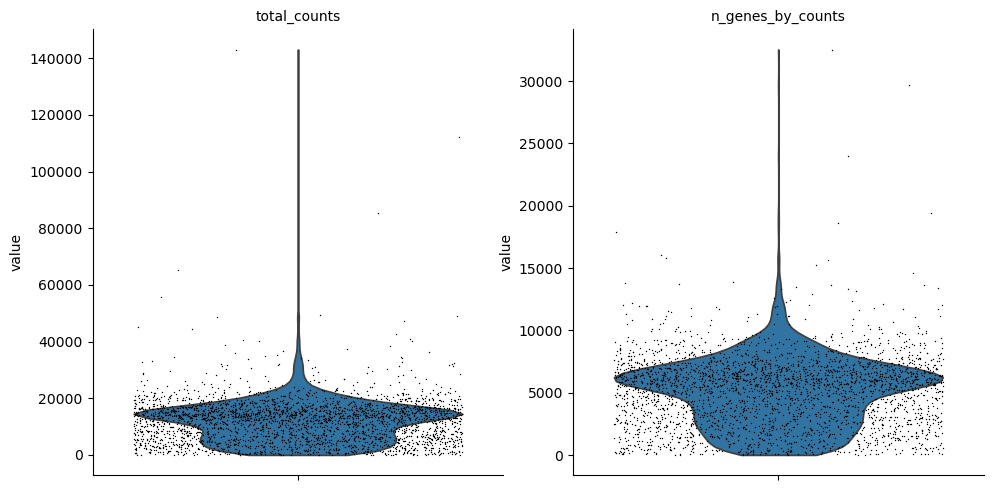

In [7]:
sc.pl.violin(
    mdata["atac"],
    ["total_counts", "n_genes_by_counts"],
    jitter=0.4,
    multi_panel=True,
)

## Doublet scores

Scrublet doublet scores are stored in `doublet_scrublet_scrublet_score` and predictions in `doublet_scrublet_scrublet_predicted_doublet` on the GEX modality.

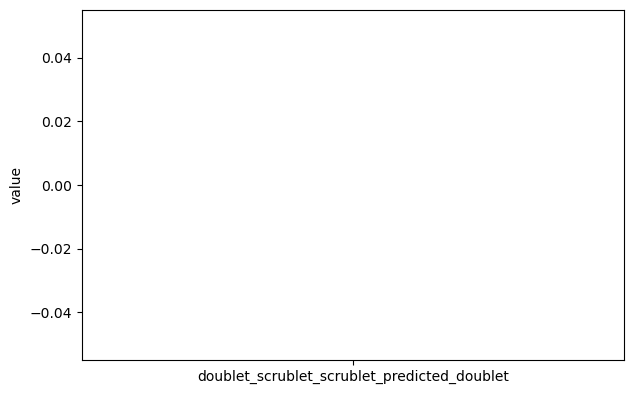

In [8]:
sc.pl.violin(
    mdata["gex"],
    "doublet_scrublet_scrublet_predicted_doublet",
    jitter=0.4,
)

In [9]:
predicted = mdata["gex"].obs["doublet_scrublet_scrublet_predicted_doublet"]
n_doublets = (predicted == 1.0).sum()
n_singlets = (predicted == 0.0).sum()

print(f"Predicted singlets : {n_singlets}")
print(f"Predicted doublets : {n_doublets} ({100 * n_doublets / len(predicted):.1f}%)")

Predicted singlets : 0
Predicted doublets : 0 (0.0%)
